# CarDD — Preprocessing: GPU Enhancement + Class-Balancing

Turns the raw CarDD YOLO dataset into a **training-ready, enhanced, class-balanced** dataset.

**Pipeline (all on GPU)**
1. Verify the **GPU / ml env** (fails loudly if CUDA missing — *runs on GPU always*).
2. **Enhance every image** with mild **unsharp masking** (chosen empirically — see §2) and
   write a consistent `enhanced/{train,val,test}` mirror.
3. Compute the **class imbalance** (~11×: `scratch` ≫ `tire_flat`).
4. Plan an **oversampling schedule** that lifts rare classes to a target.
5. Generate **bbox-aware augmentations on the GPU (Kornia)** from the *enhanced* train images.
6. Validate labels, inspect samples, write a ready-to-train **`data_balanced.yaml`**.

### Design decisions (important)
- **Enhancement is deterministic preprocessing, applied to *all* splits** (train, augmented,
  val, test) so the distribution matches. *You must apply the same `enhance()` at inference.*
- **Augmentation is applied to *train only*** — `val`/`test` are enhanced but never augmented,
  so evaluation stays honest.
- **No offline resize** — Ultralytics letterboxes to `imgsz` at train time.
- **Offline balancing + online augmentation are complementary** — keep YOLO's mosaic/HSV/flip on.
- **No vertical flip** (EDA: strong vertical structure). Geometry kept mild so rare boxes stay in frame.


## 0 · GPU / environment check  — *fails if no CUDA*

In [1]:
import torch, sys, platform
assert torch.cuda.is_available(), (
    "CUDA GPU not available. Run this in the GPU 'ml' env "
    "(`conda activate ml`) with a CUDA build of torch."
)
DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print("Python      :", sys.version.split()[0], "|", platform.system())
print("Torch       :", torch.__version__, "| CUDA", torch.version.cuda)
print("GPU         :", torch.cuda.get_device_name(0))
print("VRAM (GB)   :", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2))


Python      : 3.14.3 | Windows
Torch       : 2.13.0.dev20260529+cu126 | CUDA 12.6
GPU         : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM (GB)   : 6.44


## 1 · Imports & configuration

In [2]:
import os, shutil, random, math, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
import kornia
import kornia.augmentation as K
import yaml

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ---- paths ----
ROOT      = Path.cwd()
DATA      = ROOT / "dataset"           # raw input
ENH_DIR   = ROOT / "enhanced"          # enhanced mirror of all splits
OUT_DIR   = ROOT / "aug_train"         # augmented (balancing) train data
OUT_IMG   = OUT_DIR / "images"
OUT_LBL   = OUT_DIR / "labels"
YAML_OUT  = ROOT / "data_balanced.yaml"

CLASSES = {0:"dent", 1:"scratch", 2:"crack", 3:"glass_shatter", 4:"lamp_broken", 5:"tire_flat"}
NAMES   = [CLASSES[i] for i in range(len(CLASSES))]
SPLITS  = ["train", "val", "test"]

# ---- enhancement knobs (unsharp masking) ----
APPLY_ENHANCEMENT = True       # set False to skip enhancement entirely
USM_AMOUNT        = 0.8        # unsharp strength
USM_SIGMA         = 1.2        # blur sigma
USM_KERNEL        = (5, 5)

# ---- balancing knobs ----
TARGET_PER_CLASS   = 1500
MAX_AUG_PER_IMAGE  = 12
MIN_BOX_AREA_FRAC  = 1e-4
SAFETY_CAP_AUG     = 20000

print("Enhancement:", "ON (unsharp)" if APPLY_ENHANCEMENT else "OFF",
      f"| amount={USM_AMOUNT} sigma={USM_SIGMA}")
print(f"Balancing  : target/class={TARGET_PER_CLASS}, max aug/image={MAX_AUG_PER_IMAGE}")


Enhancement: ON (unsharp) | amount=0.8 sigma=1.2
Balancing  : target/class=1500, max aug/image=12


## 2 · Why unsharp masking? (empirical decision)

Before committing to any enhancement we measured its effect on **real damage regions**
(crack + scratch boxes) vs the **noise it adds in flat areas**, across three candidates:

| Variant | Edge energy in damage ↑ | Flat-region noise ↑ | Signal:Noise |
|---|---|---|---|
| CLAHE | +39% | **+103%** | poor (doubles noise) |
| **Unsharp mask** | **+52%** | **+13%** | **best (~4:1)** |
| CLAHE + unsharp | +90% | +123% | most signal, most noise |

CLAHE's contrast gain is real but it amplifies JPEG/compression noise heavily. **Mild unsharp
masking** sharpens the fine cracks/scratches (+52% edge energy) while barely touching flat-area
noise (+13%) — the best trade-off, so that is what we apply. *(Re-run the EDA-style metric if you
want to re-validate on your machine.)*


## 3 · Build the enhanced mirror (GPU unsharp, all splits)

In [3]:
def enhance_bgr(img_bgr):
    """GPU unsharp mask. Input/return BGR uint8 (same size). Identity if enhancement off."""
    if not APPLY_ENHANCEMENT:
        return img_bgr
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(rgb).to(DEVICE).permute(2,0,1).float().div(255.).unsqueeze(0)
    blur = kornia.filters.gaussian_blur2d(t, USM_KERNEL, (USM_SIGMA, USM_SIGMA))
    out = (t + USM_AMOUNT * (t - blur)).clamp(0, 1)
    out = out[0].permute(1,2,0).mul(255).byte().cpu().numpy()
    return cv2.cvtColor(out, cv2.COLOR_RGB2BGR)

# rebuild enhanced/ from scratch
if ENH_DIR.exists():
    shutil.rmtree(ENH_DIR)

n_enh = 0
for split in SPLITS:
    (ENH_DIR/split/"images").mkdir(parents=True, exist_ok=True)
    (ENH_DIR/split/"labels").mkdir(parents=True, exist_ok=True)
    imgs = sorted((DATA/split/"images").glob("*.jpg"))
    for p in tqdm(imgs, desc=f"enhance {split}"):
        img = cv2.imread(str(p))
        if img is None:
            continue
        cv2.imwrite(str(ENH_DIR/split/"images"/p.name), enhance_bgr(img),
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        lp = DATA/split/"labels"/f"{p.stem}.txt"
        if lp.exists():
            shutil.copy2(lp, ENH_DIR/split/"labels"/lp.name)
        n_enh += 1
print(f"\nEnhanced images written: {n_enh}  ->  {ENH_DIR}")

# active source for everything downstream = enhanced mirror (or raw if disabled)
SRC = ENH_DIR if APPLY_ENHANCEMENT else DATA
print("Downstream source:", SRC.name)


enhance train:   0%|          | 0/2816 [00:00<?, ?it/s]

enhance val:   0%|          | 0/810 [00:00<?, ?it/s]

enhance test:   0%|          | 0/374 [00:00<?, ?it/s]


Enhanced images written: 4000  ->  c:\Users\Adri\Downloads\CarDD\enhanced
Downstream source: enhanced


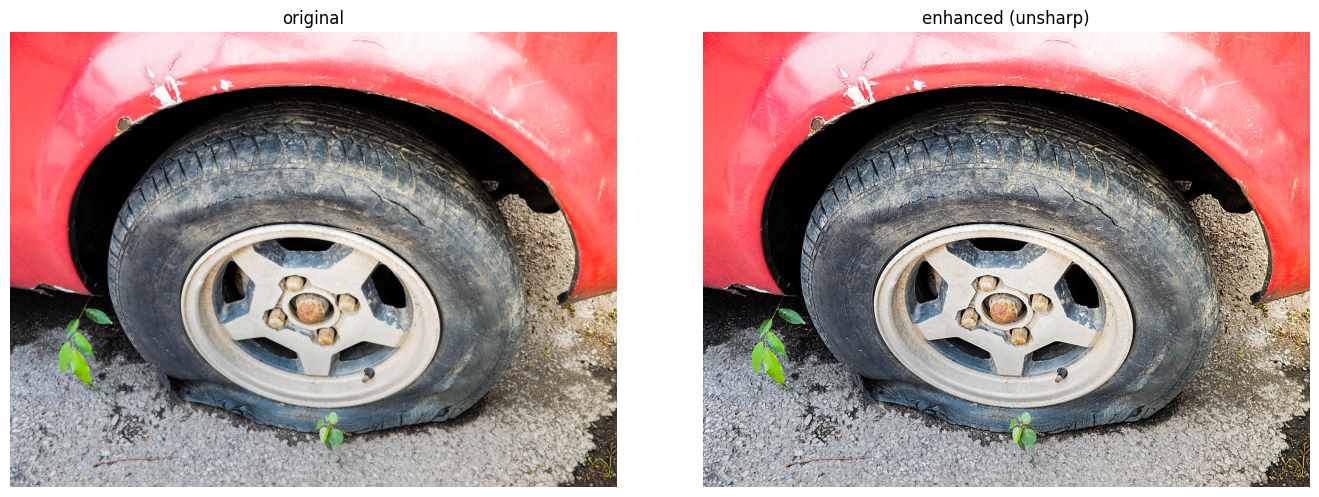

In [4]:
# show the effect on a sample (original vs enhanced)
sample_p = sorted((DATA/"train"/"images").glob("*.jpg"))[0]
orig = cv2.imread(str(sample_p)); enh = enhance_bgr(orig)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(enh, cv2.COLOR_BGR2RGB)); ax[1].set_title("enhanced (unsharp)"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## 4 · Load (enhanced) train labels & current class distribution

In [5]:
def read_yolo_label(path):
    out = []
    if not Path(path).exists():
        return out
    with open(path) as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            p = ln.split()
            if len(p) != 5:
                continue
            c = int(float(p[0])); xc, yc, w, h = map(float, p[1:])
            out.append((c, xc, yc, w, h))
    return out

TRAIN_IMG = SRC / "train" / "images"
TRAIN_LBL = SRC / "train" / "labels"

train_items, class_to_stems, orig_counts = [], defaultdict(list), Counter()
for img_path in sorted(TRAIN_IMG.glob("*.jpg")):
    stem = img_path.stem
    boxes = read_yolo_label(TRAIN_LBL / f"{stem}.txt")
    if not boxes:
        continue
    train_items.append((stem, img_path, boxes))
    for c in set(b[0] for b in boxes):
        class_to_stems[c].append(stem)
    for b in boxes:
        orig_counts[b[0]] += 1

items_by_stem = {s: (s, p, b) for (s, p, b) in train_items}
print(f"Train images with boxes: {len(train_items)}")
for c in range(6):
    print(f"  {c} {CLASSES[c]:14s}: {orig_counts[c]:5d}  (in {len(class_to_stems[c])} images)")
print(f"\nImbalance ratio: {max(orig_counts.values())/min(orig_counts.values()):.1f}x")


Train images with boxes: 2816
  0 dent          :  1806  (in 1242 images)
  1 scratch       :  2560  (in 1507 images)
  2 crack         :   651  (in 434 images)
  3 glass_shatter :   475  (in 469 images)
  4 lamp_broken   :   494  (in 489 images)
  5 tire_flat     :   225  (in 219 images)

Imbalance ratio: 11.4x


## 5 · Plan the oversampling schedule

Rarest-first greedy: while a class is below `TARGET_PER_CLASS`, schedule one augmented copy of
one of its images (round-robin, capped by `MAX_AUG_PER_IMAGE`). An augmented copy re-adds **all**
boxes in that image, so co-occurring rare classes boost each other; realized counts are recomputed
after generation (a few boxes may be clipped).


Planned augmented images: 3283 (from 1219 source images)
  dent          :  1806 ->  3381
  scratch       :  2560 ->  3783
  crack         :   651 ->  1505
  glass_shatter :   475 ->  1523
  lamp_broken   :   494 ->  1550
  tire_flat     :   225 ->  1525


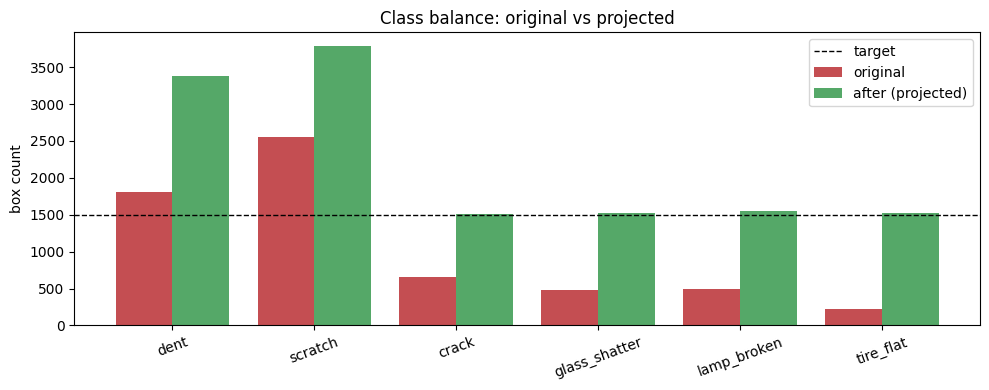

In [6]:
proj_counts = Counter(orig_counts)
aug_per_stem = Counter()
jobs = []
rng = random.Random(SEED)

for c in sorted(range(6), key=lambda c: orig_counts[c]):
    stems = class_to_stems[c][:]
    if not stems:
        continue
    rng.shuffle(stems)
    idx = stall = 0
    while proj_counts[c] < TARGET_PER_CLASS and len(jobs) < SAFETY_CAP_AUG:
        stem = stems[idx % len(stems)]; idx += 1
        if aug_per_stem[stem] >= MAX_AUG_PER_IMAGE:
            stall += 1
            if stall >= len(stems):
                break
            continue
        stall = 0
        aug_per_stem[stem] += 1
        jobs.append(stem)
        for b in items_by_stem[stem][2]:
            proj_counts[b[0]] += 1

print(f"Planned augmented images: {len(jobs)} (from {len(aug_per_stem)} source images)")
for c in range(6):
    print(f"  {CLASSES[c]:14s}: {orig_counts[c]:5d} -> {proj_counts[c]:5d}")

fig, ax = plt.subplots(figsize=(10,4)); x = np.arange(6); w = 0.4
ax.bar(x-w/2, [orig_counts[c] for c in range(6)], w, label="original", color="#c44e52")
ax.bar(x+w/2, [proj_counts[c] for c in range(6)], w, label="after (projected)", color="#55a868")
ax.axhline(TARGET_PER_CLASS, ls="--", c="k", lw=1, label="target")
ax.set_xticks(x); ax.set_xticklabels(NAMES, rotation=20); ax.set_ylabel("box count")
ax.set_title("Class balance: original vs projected"); ax.legend(); plt.tight_layout(); plt.show()


## 6 · GPU augmentation pipeline (Kornia, bbox-aware)

Mild geometry (boxes stay in frame) + photometric jitter. Photometric ops leave boxes untouched;
geometric ops transform box corners and we re-derive the axis-aligned YOLO box, clip, and drop slivers.


In [7]:
aug_pipeline = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomAffine(degrees=7, translate=(0.04, 0.04), scale=(0.9, 1.1),
                   shear=3, padding_mode="reflection", p=0.8),
    K.RandomBrightness(brightness=(0.85, 1.15), p=0.6),
    K.RandomContrast(contrast=(0.85, 1.15), p=0.6),
    K.ColorJiggle(brightness=0.0, contrast=0.0, saturation=0.2, hue=0.03, p=0.6),
    K.RandomGaussianNoise(mean=0.0, std=0.02, p=0.25),
    K.RandomGaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.2), p=0.15),
    data_keys=["input", "bbox_xyxy"], same_on_batch=False,
).to(DEVICE)

def yolo_to_xyxy(boxes, W, H):
    out = []
    for (c, xc, yc, w, h) in boxes:
        out.append([(xc-w/2)*W, (yc-h/2)*H, (xc+w/2)*W, (yc+h/2)*H])
    return np.array(out, dtype=np.float32), [b[0] for b in boxes]

def augment_image(img_path, boxes):
    img = cv2.imread(str(img_path))
    if img is None:
        return None, []
    H, W = img.shape[:2]
    t = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).to(DEVICE)\
             .permute(2,0,1).float().div(255.).unsqueeze(0)
    xyxy, classes = yolo_to_xyxy(boxes, W, H)
    bb = torch.from_numpy(xyxy).to(DEVICE).unsqueeze(0)
    out_img, out_bb = aug_pipeline(t, bb)
    out = (out_img.clamp(0,1)[0].permute(1,2,0).mul(255).byte().cpu().numpy())
    out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
    oh, ow = out_bgr.shape[:2]
    new_boxes = []
    for (x1,y1,x2,y2), c in zip(out_bb[0].detach().cpu().numpy(), classes):
        x1,x2 = sorted((float(x1), float(x2))); y1,y2 = sorted((float(y1), float(y2)))
        x1=max(0,min(x1,ow)); x2=max(0,min(x2,ow)); y1=max(0,min(y1,oh)); y2=max(0,min(y2,oh))
        bw=(x2-x1)/ow; bh=(y2-y1)/oh
        if bw<=0 or bh<=0 or bw*bh < MIN_BOX_AREA_FRAC:
            continue
        new_boxes.append((int(c), (x1+x2)/2/ow, (y1+y2)/2/oh, bw, bh))
    return out_bgr, new_boxes

print("Augmentation pipeline ready on", DEVICE)


Augmentation pipeline ready on cuda


## 7 · Quick visual sanity check

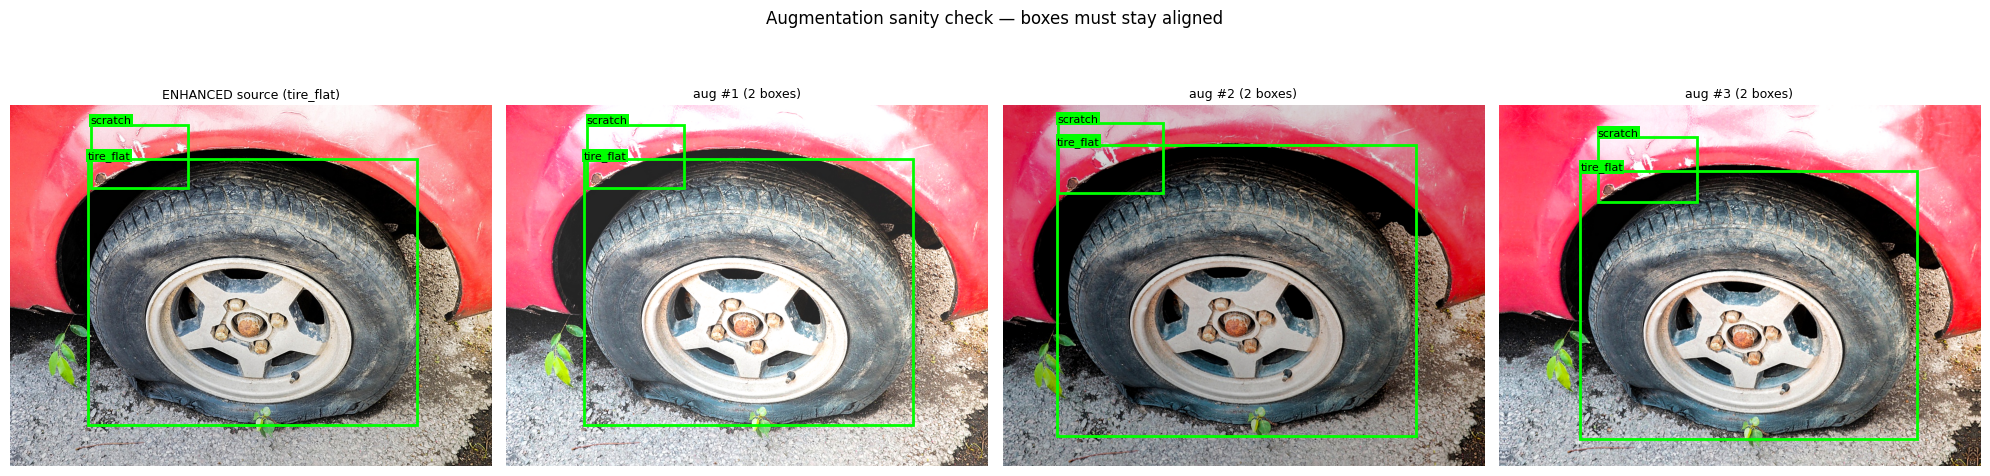

In [8]:
def draw(ax, bgr, boxes, title):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB); H, W = rgb.shape[:2]
    ax.imshow(rgb)
    for (c, xc, yc, w, h) in boxes:
        x=(xc-w/2)*W; y=(yc-h/2)*H
        ax.add_patch(patches.Rectangle((x,y), w*W, h*H, fill=False, edgecolor="lime", lw=2))
        ax.text(x, max(y-3,0), CLASSES[c], color="black", fontsize=8,
                bbox=dict(facecolor="lime", edgecolor="none", pad=1))
    ax.set_title(title, fontsize=9); ax.axis("off")

rare = min(range(6), key=lambda c: orig_counts[c])
demo_stem = class_to_stems[rare][0]
_, dpath, dboxes = items_by_stem[demo_stem]
fig, axes = plt.subplots(1, 4, figsize=(20,5))
draw(axes[0], cv2.imread(str(dpath)), dboxes, f"ENHANCED source ({CLASSES[rare]})")
for k in range(1,4):
    a_img, a_boxes = augment_image(dpath, dboxes)
    draw(axes[k], a_img, a_boxes, f"aug #{k} ({len(a_boxes)} boxes)")
plt.suptitle("Augmentation sanity check — boxes must stay aligned", y=1.02)
plt.tight_layout(); plt.show()


## 8 · Generate the balanced dataset (GPU)

In [9]:
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_IMG.mkdir(parents=True, exist_ok=True); OUT_LBL.mkdir(parents=True, exist_ok=True)

final_counts = Counter(orig_counts)
written = skipped_empty = 0
per_stem_seq = Counter()
for stem in tqdm(jobs, desc="Augmenting (GPU)"):
    _, img_path, boxes = items_by_stem[stem]
    aug_bgr, aug_boxes = augment_image(img_path, boxes)
    if aug_bgr is None or not aug_boxes:
        skipped_empty += 1; continue
    per_stem_seq[stem] += 1
    name = f"aug_{stem}_{per_stem_seq[stem]:02d}"
    cv2.imwrite(str(OUT_IMG/f"{name}.jpg"), aug_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
    with open(OUT_LBL/f"{name}.txt", "w") as f:
        for (c,xc,yc,w,h) in aug_boxes:
            f.write(f"{c} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
            final_counts[c] += 1
    written += 1

print(f"Augmented images written: {written}")
print(f"Skipped (no surviving boxes): {skipped_empty}")
print(f"Train pool: {len(train_items)} enhanced + {written} augmented = {len(train_items)+written}")


Augmenting (GPU):   0%|          | 0/3283 [00:00<?, ?it/s]

Augmented images written: 3283
Skipped (no surviving boxes): 0
Train pool: 2816 enhanced + 3283 augmented = 6099


## 9 · Validate every generated label

In [10]:
bad = []; n_checked = 0
files = list(OUT_LBL.glob("*.txt"))
for lp in files:
    for i, ln in enumerate(open(lp), 1):
        ln = ln.strip()
        if not ln:
            continue
        n_checked += 1
        p = ln.split(); ok = (len(p) == 5)
        if ok:
            c = int(float(p[0])); v = list(map(float, p[1:]))
            ok = (c in CLASSES) and all(0 <= x <= 1 for x in v) and v[2] > 0 and v[3] > 0
        if not ok:
            bad.append((lp.name, i, ln))
print(f"Checked {n_checked} boxes across {len(files)} files. Invalid: {len(bad)}")
for b in bad[:10]:
    print("  ", b)
assert not bad, "Invalid generated labels found."
print("All generated labels are valid, in-range YOLO format.")


Checked 7050 boxes across 3283 files. Invalid: 0
All generated labels are valid, in-range YOLO format.


## 10 · Final class distribution

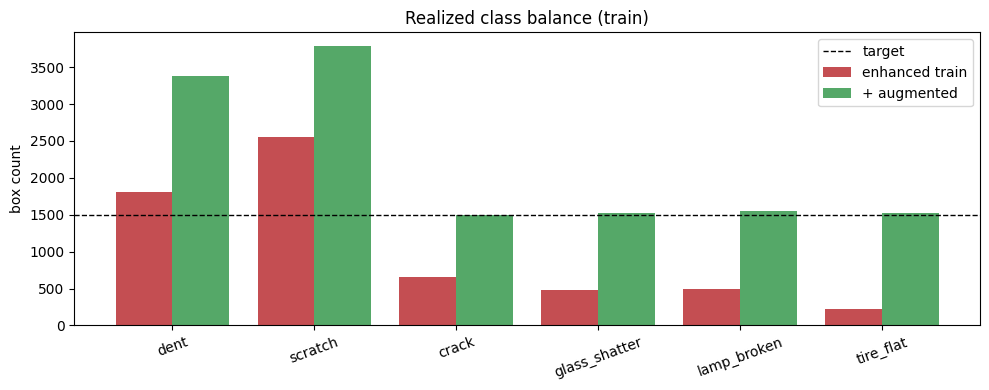

,class,before,after,added
0,dent,1806,3377,1571
1,scratch,2560,3783,1223
2,crack,651,1503,852
3,glass_shatter,475,1523,1048
4,lamp_broken,494,1550,1056
5,tire_flat,225,1525,1300


Imbalance ratio: 11.4x  ->  2.5x


In [11]:
fig, ax = plt.subplots(figsize=(10,4)); x = np.arange(6); w = 0.4
ax.bar(x-w/2, [orig_counts[c] for c in range(6)], w, label="enhanced train", color="#c44e52")
ax.bar(x+w/2, [final_counts[c] for c in range(6)], w, label="+ augmented", color="#55a868")
ax.axhline(TARGET_PER_CLASS, ls="--", c="k", lw=1, label="target")
ax.set_xticks(x); ax.set_xticklabels(NAMES, rotation=20); ax.set_ylabel("box count")
ax.set_title("Realized class balance (train)"); ax.legend(); plt.tight_layout(); plt.show()

tbl = pd.DataFrame({"class": NAMES,
                    "before": [orig_counts[c]  for c in range(6)],
                    "after":  [final_counts[c] for c in range(6)]})
tbl["added"] = tbl["after"] - tbl["before"]
display(tbl)
print(f"Imbalance ratio: {max(orig_counts.values())/min(orig_counts.values()):.1f}x"
      f"  ->  {max(final_counts.values())/min(final_counts.values()):.1f}x")


## 11 · Write `data_balanced.yaml`

In [12]:
src_name = SRC.name  # 'enhanced' (or 'dataset' if enhancement off)
data_yaml = {
    "path": str(ROOT).replace("\\", "/"),
    "train": [f"{src_name}/train/images", f"{OUT_DIR.name}/images"],
    "val":   f"{src_name}/val/images",
    "test":  f"{src_name}/test/images",
    "nc": 6,
    "names": {i: NAMES[i] for i in range(6)},
}
with open(YAML_OUT, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)
print("Wrote", YAML_OUT, "\n" + "-"*50)
print(open(YAML_OUT).read())


Wrote c:\Users\Adri\Downloads\CarDD\data_balanced.yaml 
--------------------------------------------------
path: c:/Users/Adri/Downloads/CarDD
train:
- enhanced/train/images
- aug_train/images
val: enhanced/val/images
test: enhanced/test/images
nc: 6
names:
  0: dent
  1: scratch
  2: crack
  3: glass_shatter
  4: lamp_broken
  5: tire_flat



## 12 · Summary & how to train

**Artifacts**
- `enhanced/{train,val,test}` — unsharp-enhanced mirror of every split (deterministic).
- `aug_train/{images,labels}` — GPU-augmented, class-balancing copies (train only, from enhanced).
- `data_balanced.yaml` — train = *enhanced train + augmented*; val/test = *enhanced* (never augmented).

**Train (Ultralytics YOLO, GPU):**
```bash
yolo detect train data=data_balanced.yaml model=yolov8m.pt \
     imgsz=1024 epochs=120 batch=8 device=0 \
     close_mosaic=15 fliplr=0.5 flipud=0.0
```

**⚠️ Inference must match preprocessing.** Because every split was unsharp-enhanced, apply the
**same `enhance_bgr()`** to any new image before predicting, e.g.:
```python
img = enhance_bgr(cv2.imread(path)); model.predict(img)
```
(Or set `APPLY_ENHANCEMENT=False` and re-run if you prefer a no-enhancement pipeline — then train on raw `dataset/`.)

**Why these choices**
- `imgsz=1024` protects small `crack`/`scratch` (EDA: ~29% of boxes <3% of image area).
- Unsharp enhancement: +52% edge energy in damage regions at only +13% flat-area noise (empirically chosen over CLAHE).
- Balancing lifts rare classes to ~1500 (imbalance 11×→~2.5×) without over-duplicating any single image (`MAX_AUG_PER_IMAGE`).
- `flipud=0.0`: no vertical flip; `close_mosaic=15`: stop mosaic late so tiny boxes survive.
- Report **per-class AP** — overall mAP is dominated by majority classes.

Re-running rebuilds `enhanced/` and `aug_train/` deterministically (seeded).
